<a href="https://colab.research.google.com/github/Sidahmed8/retail-sales-forecasting-shap/blob/main/retail_sales_forecasting_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prévision des ventes retail (scikit-learn + SHAP)

Ce notebook est un **template prêt à l’emploi** pour :
- préparer des données retail (séries temporelles),
- créer des **features temporelles + lags + rolling**,
- entraîner et comparer des modèles de régression (baseline, Ridge, RandomForest, GradientBoosting),
- évaluer (MAE, RMSE, R²),
- interpréter le meilleur modèle avec **SHAP** (global + local).

✅ **À faire par toi** : fournir un CSV avec au minimum :
- une colonne date (ex: `date`)
- une colonne cible (ex: `sales`)

Optionnel : colonnes catégorielles (ex: `store`, `product`, `category`) et numériques (ex: `price`, `promo`).


In [ ]:
# Install (si besoin) - à exécuter seulement si SHAP n'est pas installé
# !pip -q install shap

In [ ]:
import numpy as np


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import shap

## 1) Charger les données

### Format attendu (exemple)
| date | sales | store | product | promo | price |
|------|-------|-------|---------|-------|-------|

- `date` : datetime (jour/semaine)
- `sales` : cible (quantité ou CA)
- `store/product/category` : optionnel (catégorielles)
- `promo/price` : optionnel (numériques)


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'retail_sales_forecasting_shap_template.ipynb', 'retail_sales_data.csv', 'sample_data']


In [ ]:
# ---- À MODIFIER ----
CSV_PATH = "/content/retail_sales_data.csv"     # chemin vers ton fichier
DATE_COL = "date"         # nom de colonne date
TARGET_COL = "sales"      # nom de colonne cible

df = pd.read_csv(CSV_PATH)

# conversion date
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET_COL]).sort_values(DATE_COL).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())


Shape: (13152, 6)


,date,store,product,promo,price,sales
0,2022-01-01,S1,A,0,19.41,56.0
1,2022-01-01,S3,D,0,13.28,46.2
2,2022-01-01,S3,C,0,10.05,47.2
3,2022-01-01,S3,B,0,8.56,49.3
4,2022-01-01,S2,D,0,12.40,49.9


## 2) Feature engineering (temps + lags + rolling)

> Les features de lag/rolling capturent l'historique des ventes (très utile en retail).


In [ ]:
def add_time_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    out = df.copy()
    dt = out[date_col]
    out["year"] = dt.dt.year
    out["month"] = dt.dt.month
    out["week"] = dt.dt.isocalendar().week.astype(int)
    out["day"] = dt.dt.day
    out["dayofweek"] = dt.dt.dayofweek
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["quarter"] = dt.dt.quarter
    return out

def add_lag_rolling_features(
    df: pd.DataFrame,
    group_cols: list,
    target_col: str,
    lags=(1, 7, 14, 28),
    rolls=(7, 14, 28)
) -> pd.DataFrame:
    out = df.copy()

    # tri obligatoire
    if group_cols:
        out = out.sort_values(group_cols + [DATE_COL]).reset_index(drop=True)
        g = out.groupby(group_cols, dropna=False)[target_col]
        for lag in lags:
            out[f"{target_col}_lag_{lag}"] = g.shift(lag)
        for w in rolls:
            out[f"{target_col}_rollmean_{w}"] = g.shift(1).rolling(w).mean()
            out[f"{target_col}_rollstd_{w}"] = g.shift(1).rolling(w).std()
    else:
        out = out.sort_values([DATE_COL]).reset_index(drop=True)
        s = out[target_col]
        for lag in lags:
            out[f"{target_col}_lag_{lag}"] = s.shift(lag)
        for w in rolls:
            out[f"{target_col}_rollmean_{w}"] = s.shift(1).rolling(w).mean()
            out[f"{target_col}_rollstd_{w}"] = s.shift(1).rolling(w).std()

    return out


# ---- À MODIFIER si besoin ----
# Si tu as une seule série globale, laisse group_cols=[]
# Si tu as plusieurs magasins/produits, mets par ex: group_cols=["store"] ou ["store","product"]
group_cols = []  # ex: ["store"]

df_feat = add_time_features(df, DATE_COL)
df_feat = add_lag_rolling_features(df_feat, group_cols, TARGET_COL)

# supprimer les lignes du début qui ont des NaN à cause des lags/rolling
df_feat = df_feat.dropna().reset_index(drop=True)

print("Après features:", df_feat.shape)
display(df_feat.head())


Après features: (13124, 23)


,date,store,product,promo,price,sales,year,month,week,day,...,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_rollmean_7,sales_rollstd_7,sales_rollmean_14,sales_rollstd_14,sales_rollmean_28,sales_rollstd_28
0,2022-01-03,S1,D,0,13.93,47.3,2022,1,1,3,...,63.6,56.4,61.5,56.0,51.171429,7.985761,53.571429,7.579266,52.385714,6.457423
1,2022-01-03,S1,C,0,16.56,39.4,2022,1,1,3,...,47.3,40.7,46.0,49.5,49.871429,7.729320,52.557143,7.384257,52.075000,6.486318
2,2022-01-03,S3,C,1,14.47,47.7,2022,1,1,3,...,39.4,48.5,51.1,63.0,49.685714,7.997381,52.085714,8.018523,51.714286,6.902319
3,2022-01-03,S3,A,0,9.93,57.4,2022,1,1,3,...,47.7,50.7,54.0,51.4,49.571429,8.022825,51.842857,8.101730,51.167857,6.573575
4,2022-01-03,S3,B,0,10.24,49.2,2022,1,1,3,...,57.4,43.0,52.7,57.5,50.528571,8.561486,52.085714,8.221441,51.382143,6.678382


## 3) Split chronologique (train/test)

On garde la dernière partie du temps pour tester (réaliste en série temporelle).


In [ ]:
# ---- À MODIFIER ----
TEST_RATIO = 0.2  # 20% du temps en test

n = len(df_feat)
split_idx = int(n * (1 - TEST_RATIO))

train_df = df_feat.iloc[:split_idx].copy()
test_df  = df_feat.iloc[split_idx:].copy()

print("Train:", train_df.shape, "Test:", test_df.shape)
print("Train dates:", train_df[DATE_COL].min(), "->", train_df[DATE_COL].max())
print("Test  dates:", test_df[DATE_COL].min(),  "->", test_df[DATE_COL].max())


Train: (10499, 23) Test: (2625, 23)
Train dates: 2022-01-03 00:00:00 -> 2024-05-27 00:00:00
Test  dates: 2024-05-27 00:00:00 -> 2024-12-31 00:00:00


## 4) Préparation X/y + prétraitement (catégorielles/numériques)

On utilise un `ColumnTransformer` pour un pipeline propre (recruteur-friendly).


In [ ]:
# Séparation X/y
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL].astype(float)

X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL].astype(float)

# On retire la colonne date des features (on garde les features temporelles déjà créées)
X_train = X_train.drop(columns=[DATE_COL])
X_test  = X_test.drop(columns=[DATE_COL])

# Détection auto des colonnes
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numerical:", num_cols[:10], "... total:", len(num_cols))

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ],
    remainder="drop"
)


Categorical: ['store', 'product']
Numerical: ['promo', 'price', 'year', 'month', 'week', 'day', 'dayofweek', 'is_weekend', 'quarter', 'sales_lag_1'] ... total: 19


## 5) Baseline + Modèles (Ridge / RandomForest / GradientBoosting)

On compare plusieurs modèles et on choisit le meilleur selon RMSE/MAE.


In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# Baseline simple : prédire la moyenne des ventes du train
baseline_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=float)
b_mae, b_rmse, b_r2 = evaluate(y_test, baseline_pred)

results = []
results.append(("Baseline(mean)", b_mae, b_rmse, b_r2))

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1, max_depth=None
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

fitted = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae, rmse, r2 = evaluate(y_test, pred)
    results.append((name, mae, rmse, r2))
    fitted[name] = pipe

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
display(results_df)


,Model,MAE,RMSE,R2
1,Ridge,4.399767,5.552695,0.755531
3,GradientBoosting,4.439908,5.566168,0.754344
2,RandomForest,4.712926,5.958722,0.718472
0,Baseline(mean),9.586466,11.787933,-0.101769


### Visualiser prédictions vs réel (meilleur modèle)

Best model: Ridge


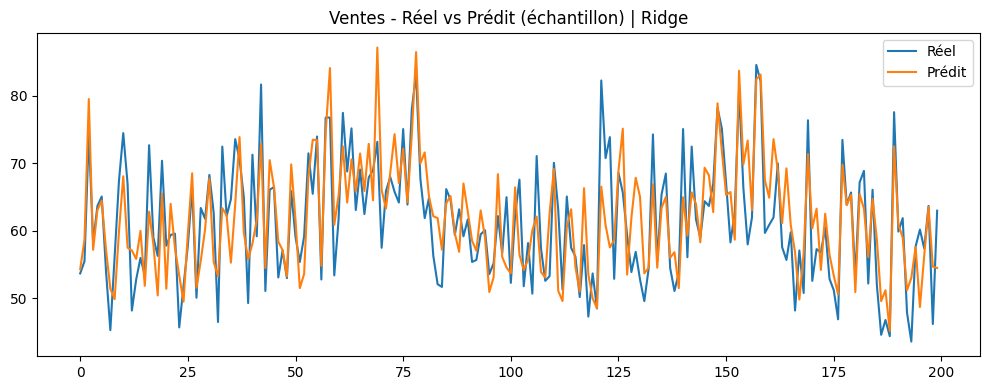

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "Baseline(mean)":
    y_pred_best = baseline_pred
else:
    y_pred_best = fitted[best_model_name].predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Réel")
plt.plot(y_pred_best[:200], label="Prédit")
plt.title(f"Ventes - Réel vs Prédit (échantillon) | {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 6) Interprétation avec SHAP

On applique SHAP sur le meilleur modèle **Tree-based** si possible (RandomForest / GradientBoosting).
Si le meilleur modèle est Ridge, on peut faire une interprétation via coefficients (optionnel).


In [ ]:
best_name = best_model_name

if best_name in ["RandomForest", "GradientBoosting"]:
    best_pipe = fitted[best_name]
    # Récupérer la matrice transformée après preprocessing
    X_train_trans = best_pipe.named_steps["prep"].transform(X_train)
    X_test_trans  = best_pipe.named_steps["prep"].transform(X_test)

    # Récupérer les noms des features après OneHot
    feat_names = []
    # num
    feat_names += num_cols
    # cat onehot names
    if len(cat_cols) > 0:
        ohe = best_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feat_names += ohe_names

    model = best_pipe.named_steps["model"]

    # SHAP Explainer (TreeExplainer fonctionne bien pour arbres)
    explainer = shap.TreeExplainer(model)
    # Pour la vitesse, on prend un sous-échantillon
    sample_size = min(1000, X_test_trans.shape[0])
    X_shap = X_test_trans[:sample_size]

    shap_values = explainer.shap_values(X_shap)

    # Summary plot (global)
    shap.summary_plot(shap_values, X_shap, feature_names=feat_names, show=False)
    plt.tight_layout()
    plt.show()

    # Waterfall plot (local) sur une observation
    i = 0
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[i],
        feature_names=feat_names,
        features=X_shap[i],
        show=False
    )
    plt.tight_layout()
    plt.show()

else:
    print("Le meilleur modèle n'est pas un arbre. Pour Ridge, l'interprétation peut se faire via les coefficients.")


NameError: name 'best_model_name' is not defined

## 7) (Optionnel) TimeSeriesSplit CV rapide

Utile pour montrer une validation solide (recruteur/jury).


In [ ]:
# ---- Optionnel : validation croisée temporelle ----
# Attention : peut prendre du temps pour RandomForest

tscv = TimeSeriesSplit(n_splits=5)
name = "GradientBoosting"  # change si tu veux
pipe = Pipeline(steps=[("prep", preprocess), ("model", models[name])])

maes, rmses, r2s = [], [], []

X_all = df_feat.drop(columns=[TARGET_COL, DATE_COL])
y_all = df_feat[TARGET_COL].astype(float)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_val = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[tr_idx], y_all.iloc[val_idx]

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_val)

    mae, rmse, r2 = evaluate(y_val, pred)
    maes.append(mae); rmses.append(rmse); r2s.append(r2)
    print(f"Fold {fold+1}: MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")

print("\nCV Summary:")
print(f"MAE  mean={np.mean(maes):.3f} std={np.std(maes):.3f}")
print(f"RMSE mean={np.mean(rmses):.3f} std={np.std(rmses):.3f}")
print(f"R2   mean={np.mean(r2s):.3f} std={np.std(r2s):.3f}")


Fold 1: MAE=9.132 RMSE=10.893 R2=-0.199
Fold 2: MAE=4.512 RMSE=5.632 R2=0.681
Fold 3: MAE=4.315 RMSE=5.391 R2=0.718
Fold 4: MAE=4.526 RMSE=5.654 R2=0.682
Fold 5: MAE=4.439 RMSE=5.583 R2=0.718

CV Summary:
MAE  mean=5.385 std=1.875
RMSE mean=6.631 std=2.133
R2   mean=0.520 std=0.360
